<a href="https://www.kaggle.com/code/sonawanelalitsunil/country-wise-quality-of-life-comparison-ml-98?scriptVersionId=225331907" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/quality-of-life-index-by-country/quality_of_life_indices_by_country.csv


<a id="A"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:10px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:skyblue; overflow:hidden"><b>Title: 📊 Global Quality of Life Index: A Country-Wise Comparative Analysis 🌍🏡</b></div>

## Dataset Description:
**This dataset provides a comparative analysis of quality of life across different countries, incorporating multiple factors that contribute to overall well-being. It typically includes economic, environmental, and social indicators that help assess living conditions globally.**

#### Common Features in the Dataset:

**Country** – Name of the country

**Quality of Life Index** – A composite score indicating overall quality of life

**Cost of Living Index** – Average cost of goods and services

**Purchasing Power Index** – Strength of consumer purchasing power

**Safety Index** – Crime rates and overall safety perception

**Health Care Index** – Quality, accessibility, and efficiency of healthcare

**Climate Index** – Favorability of weather conditions

**Pollution Index** – Air, water, and environmental pollution levels

**Traffic Commute Time Index** – Average daily commute times

<a id="A"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:5px; color:white; margin:0; font-size:90%; font-family:Pacifico; background-color:skyblue; overflow:hidden"><b> Import Libraries </b></div>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

<a id="A"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:5px; color:white; margin:0; font-size:90%; font-family:Pacifico; background-color:skyblue; overflow:hidden"><b> Data Analyisis and Visualization</b></div>

In [3]:
df = pd.read_csv(r'/kaggle/input/quality-of-life-index-by-country/quality_of_life_indices_by_country.csv')

In [4]:
df.head()

,Rank,Country,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Climate Index,Year
0,1,Switzerland,222.9,146.5,73.2,66.3,126.0,7.3,25.6,24.1,-,2015
1,2,Germany,195.9,111.8,71.5,75.6,76.3,6.6,31.1,28.3,-,2015
2,3,Sweden,193.9,110.9,57.9,76.3,82.9,9.2,26.9,15.1,-,2015
3,4,United States,192.5,126.1,50.0,67.8,76.5,2.6,36.0,31.4,-,2015
4,5,Finland,190.2,101.2,70.5,69.4,89.7,7.0,33.2,14.9,-,2015


In [5]:
df.tail()

,Rank,Country,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Climate Index,Year
1490,79,Peru,84.6,34.8,32.7,56.3,30.0,18.3,48.9,82.5,97.7,2024/2
1491,80,Iran,80.4,26.0,49.7,52.5,26.4,23.4,46.4,75.3,71.0,2024/2
1492,81,Sri Lanka,75.2,17.5,57.9,71.0,34.6,39.1,54.6,58.5,59.1,2024/2
1493,82,Bangladesh,72.6,33.1,38.4,42.2,22.5,12.3,57.6,85.6,71.3,2024/2
1494,83,Nigeria,42.7,11.0,33.3,48.2,31.4,23.9,64.2,88.2,60.8,2024/2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Rank                            1495 non-null   int64  
 1   Country                         1495 non-null   object 
 2   Quality of Life Index           1495 non-null   float64
 3   Purchasing Power Index          1495 non-null   float64
 4   Safety Index                    1495 non-null   float64
 5   Health Care Index               1495 non-null   float64
 6   Cost of Living Index            1495 non-null   float64
 7   Property Price to Income Ratio  1495 non-null   float64
 8   Traffic Commute Time Index      1495 non-null   float64
 9   Pollution Index                 1495 non-null   float64
 10  Climate Index                   1495 non-null   object 
 11  Year                            1495 non-null   object 
dtypes: float64(8), int64(1), object(3)

In [7]:
df.describe()

,Rank,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index
count,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000
mean,38.733779,134.156656,66.804615,60.104682,65.211037,53.440401,12.876856,35.792508,52.431237
std,22.931071,40.828402,33.282943,13.776743,10.150324,20.573712,8.475637,7.905525,20.660280
min,1.000000,-53.000000,3.300000,14.700000,28.300000,17.600000,2.600000,11.800000,11.500000
25%,19.000000,105.350000,38.350000,52.700000,57.600000,36.900000,8.400000,29.900000,33.750000
50%,38.000000,136.200000,60.700000,59.900000,66.400000,49.200000,11.100000,34.900000,56.100000
75%,57.000000,165.700000,91.800000,70.700000,73.250000,69.100000,14.700000,40.250000,67.650000
max,87.000000,285.800000,210.000000,88.100000,88.400000,138.200000,202.100000,65.200000,96.600000


In [8]:
df.dtypes

Rank                                int64
Country                            object
Quality of Life Index             float64
Purchasing Power Index            float64
Safety Index                      float64
Health Care Index                 float64
Cost of Living Index              float64
Property Price to Income Ratio    float64
Traffic Commute Time Index        float64
Pollution Index                   float64
Climate Index                      object
Year                               object
dtype: object

In [9]:
df.shape

(1495, 12)

In [10]:
df.isnull().sum()

Rank                              0
Country                           0
Quality of Life Index             0
Purchasing Power Index            0
Safety Index                      0
Health Care Index                 0
Cost of Living Index              0
Property Price to Income Ratio    0
Traffic Commute Time Index        0
Pollution Index                   0
Climate Index                     0
Year                              0
dtype: int64

In [11]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1490    False
1491    False
1492    False
1493    False
1494    False
Length: 1495, dtype: bool

In [12]:
df.columns

Index(['Rank', 'Country', 'Quality of Life Index', 'Purchasing Power Index',
       'Safety Index', 'Health Care Index', 'Cost of Living Index',
       'Property Price to Income Ratio', 'Traffic Commute Time Index',
       'Pollution Index', 'Climate Index', 'Year'],
      dtype='object')

In [13]:
import plotly.express as px
fig = px.choropleth(df, 
                    locations="Country", 
                    locationmode="country names",  
                    color="Quality of Life Index", 
                    hover_name="Country",
                    animation_frame="Year",  
                    color_continuous_scale="Plasma",  # Vibrant perceptual scale
                    title="📊 Quality of Life Index by Country Over Time 🌍🏡",
                    projection="natural earth"  # More realistic world view
)

# Enhancing Map Style
fig.update_layout(
    geo=dict(
        showcoastlines=True, coastlinecolor="black",  # Highlight country borders
        showland=True, landcolor="lightgray",
        showocean=True, oceancolor="lightblue"
    ),
    coloraxis_colorbar=dict(
        title="Quality of Life Index",
        tickprefix="", ticks="outside"
    ),
    font=dict(family="Arial", size=14),  # Improve readability
    title_x=0.5  # Center-align the title
)

# Adding interactivity
fig.update_traces(
    hovertemplate="<b>%{hovertext}</b><br>Quality of Life: %{z:.2f}<extra></extra>"
)

# Display the interactive map
fig.show(renderer="iframe")


In [14]:
import plotly.express as px
import plotly.graph_objects as go

metrics = {
    "Quality of Life Index": "Viridis",
    "Cost of Living Index": "Cividis",
    "Purchasing Power Index": "Turbo",
    "Safety Index": "Blues",
    "Health Care Index": "RdYlGn",
    "Pollution Index": "Inferno",
    "Traffic Commute Time Index": "Plasma"
}

fig = go.Figure()

for i, (metric, color_scale) in enumerate(metrics.items()):
    fig.add_trace(
        go.Choropleth(
            locations=df["Country"],
            locationmode="country names",
            z=df[metric],
            colorscale=color_scale,
            text=df["Country"],
            colorbar_title=metric,
            visible=(i == 0)  # Show only first by default
        )
    )

fig.update_layout(
    updatemenus=[{
        "buttons": [
            {"label": metric, 
             "method": "update", 
             "args": [{"visible": [j == i for j in range(len(metrics))]}]} 
            for i, metric in enumerate(metrics)
        ],
        "direction": "down",
        "showactive": True,
        "x": 0.15,
        "y": 1.15
    }],
    geo=dict(showcoastlines=True, showland=True, landcolor="lightgray"),
    title_text="🌍 Quality of Life & Related Indexes by Country 🏡",
    title_x=0.5
)
fig.show(renderer="iframe")

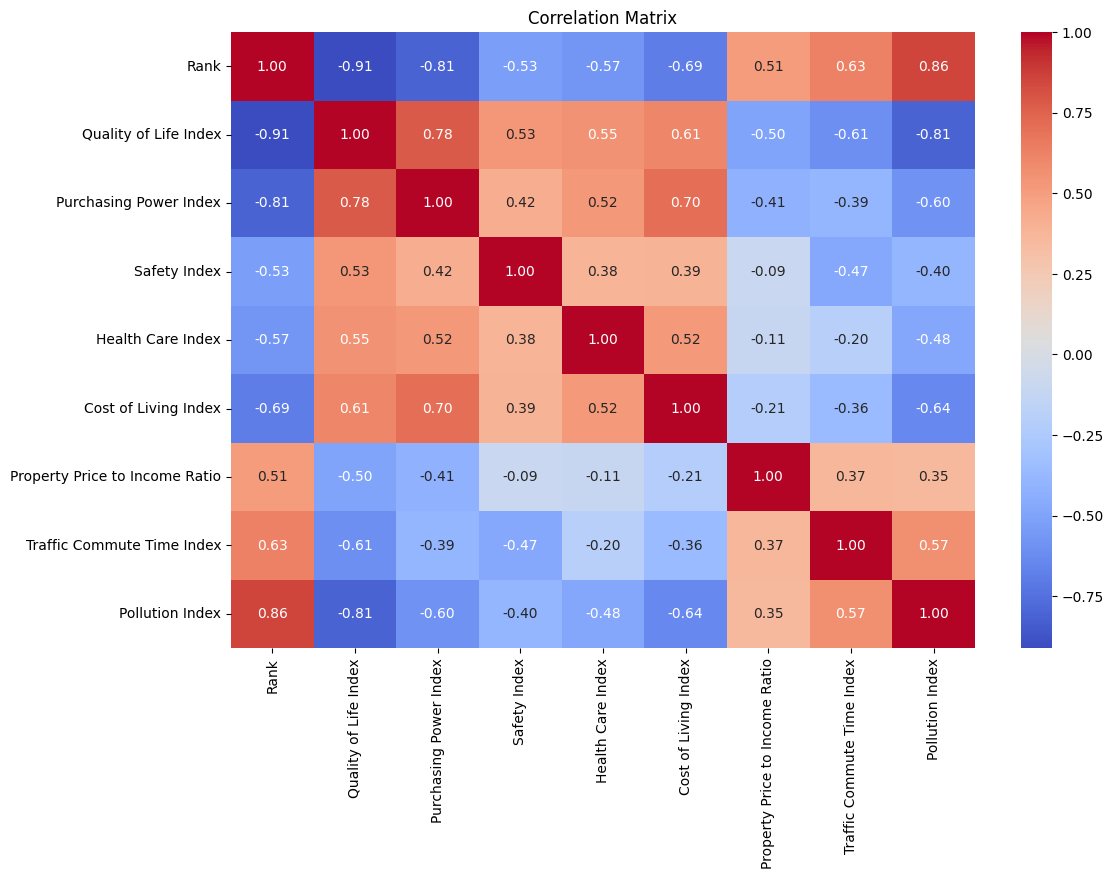

In [15]:
numeric_columns = df.select_dtypes(include=np.number)
correlation_matrix = numeric_columns.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

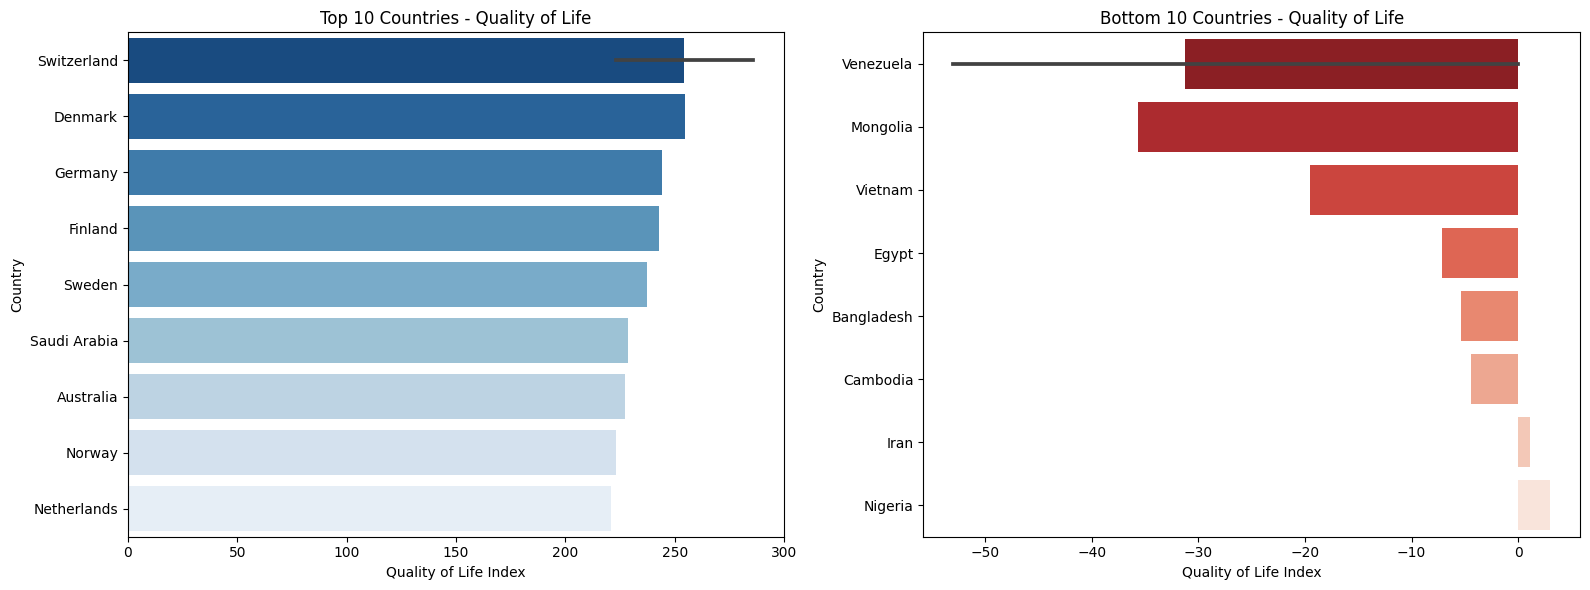

In [16]:
top_10 = df.nlargest(10, 'Quality of Life Index')
bottom_10 = df.nsmallest(10, 'Quality of Life Index')

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_10, y='Country', x='Quality of Life Index', ax=ax[0], palette='Blues_r')
ax[0].set_title('Top 10 Countries - Quality of Life')
ax[0].set_xlabel('Quality of Life Index')

sns.barplot(data=bottom_10, y='Country', x='Quality of Life Index', ax=ax[1], palette='Reds_r')
ax[1].set_title('Bottom 10 Countries - Quality of Life')
ax[1].set_xlabel('Quality of Life Index')

plt.tight_layout()
plt.show()

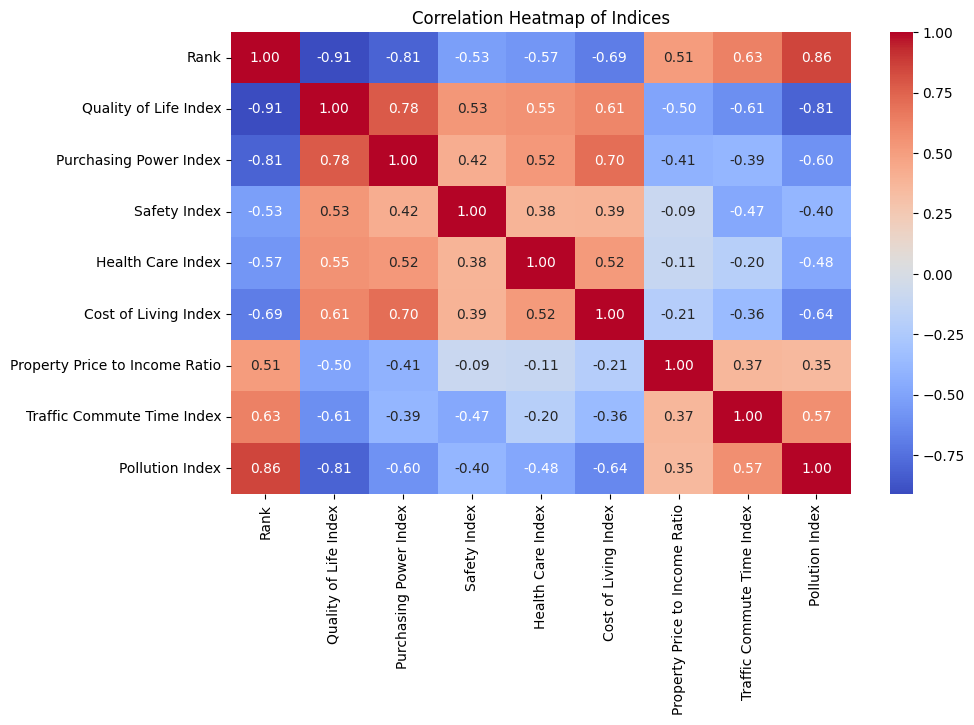

In [17]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Indices')
plt.show()

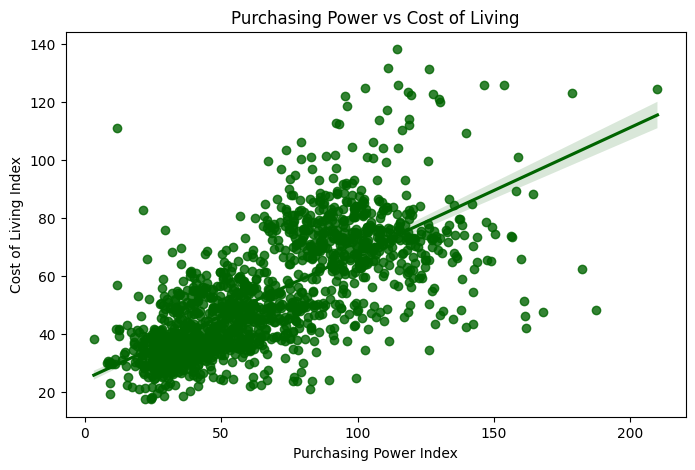

In [18]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Purchasing Power Index', y='Cost of Living Index', color='darkgreen')
plt.title('Purchasing Power vs Cost of Living')
plt.xlabel('Purchasing Power Index')
plt.ylabel('Cost of Living Index')
plt.show()

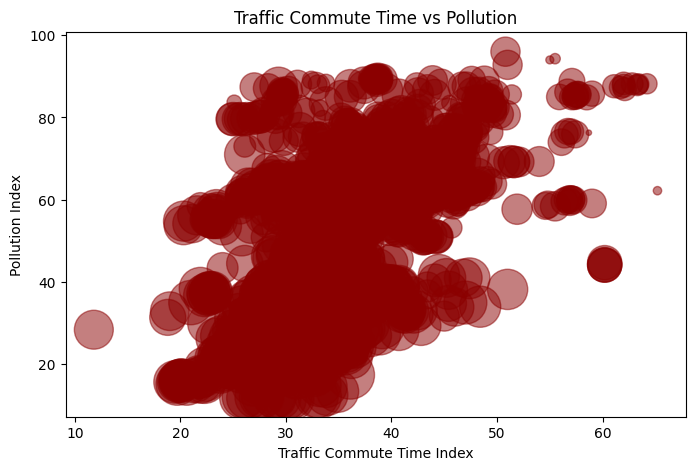

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Traffic Commute Time Index'], df['Pollution Index'], s=df['Quality of Life Index']*5, alpha=0.5, c='darkred')
plt.xlabel('Traffic Commute Time Index')
plt.ylabel('Pollution Index')
plt.title('Traffic Commute Time vs Pollution')
plt.show()

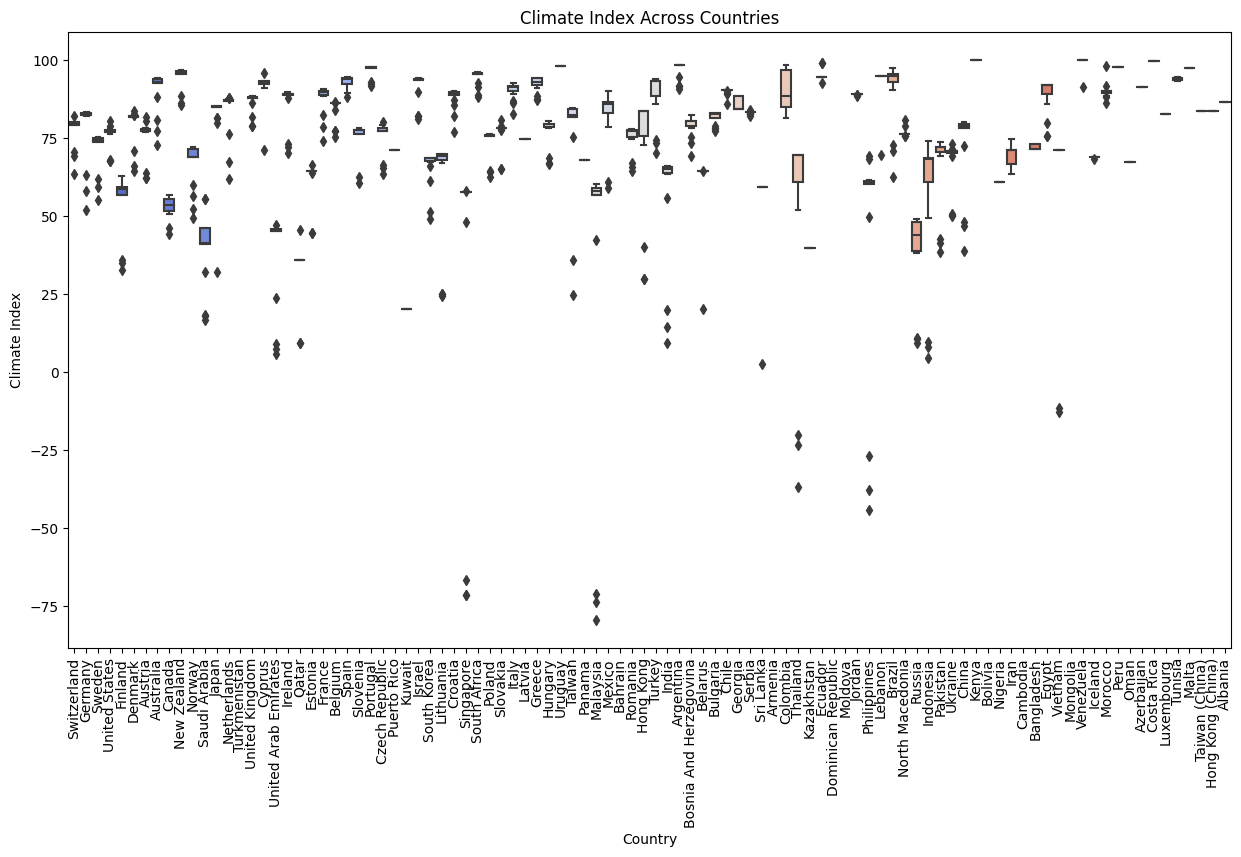

In [20]:
df['Climate Index'] = pd.to_numeric(df['Climate Index'], errors='coerce')

plt.figure(figsize=(15, 8))
sns.boxplot(data=df, y='Climate Index', x='Country', palette='coolwarm')

plt.xticks(rotation=90)
plt.title('Climate Index Across Countries')
plt.show()

In [21]:
print(df["Year"].unique())

['2015' '2015/2' '2016' '2016/2' '2017' '2017/2' '2018' '2018/2' '2019'
 '2019/2' '2020' '2020/2' '2021' '2021/2' '2022' '2022/2' '2023' '2023/2'
 '2024' '2024/2']


In [22]:
df["Year"] = df["Year"].astype(str).str[:4].astype(int)

In [23]:
print(df["Year"].unique())  

[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]


In [24]:
print(df.dtypes) 

Rank                                int64
Country                            object
Quality of Life Index             float64
Purchasing Power Index            float64
Safety Index                      float64
Health Care Index                 float64
Cost of Living Index              float64
Property Price to Income Ratio    float64
Traffic Commute Time Index        float64
Pollution Index                   float64
Climate Index                     float64
Year                                int64
dtype: object


In [25]:
top_quality_of_life = df.sort_values(by='Quality of Life Index', ascending=False).head(10)

In [26]:
print(top_quality_of_life[['Country', 'Quality of Life Index']])

         Country  Quality of Life Index
86   Switzerland                  285.8
87       Denmark                  254.7
88       Germany                  244.3
89       Finland                  242.7
90        Sweden                  237.2
91  Saudi Arabia                  228.5
92     Australia                  227.2
93        Norway                  223.0
0    Switzerland                  222.9
94   Netherlands                  220.8


<a id="A"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:5px; color:white; margin:0; font-size:90%; font-family:Pacifico; background-color:skyblue; overflow:hidden"><b> Splitting Dataset </b></div>

#### Steps:
Data Preprocessing

Handle missing values

Scale numerical features

Split into training and testing sets

#### Model Selection

Try regression models since Quality of Life Index is likely a continuous variable.

Model Training & Evaluation

Train multiple models and compare performance using metrics like RMSE, MAE, and R².

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [28]:
x_features = df.select_dtypes(include=np.number).drop(columns=['Quality of Life Index'])
y_target = df['Quality of Life Index']

<a id="A"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:5px; color:white; margin:0; font-size:90%; font-family:Pacifico; background-color:skyblue; overflow:hidden"><b> Building the Model </b></div>

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x_features, y_target, test_size=0.2, random_state=42)

In [30]:
from sklearn.impute import SimpleImputer

In [31]:
imputer = SimpleImputer(strategy='mean')  
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [33]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [34]:
y_pred = rf_model.predict(X_test_scaled)

In [35]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

MAE: 3.6519, RMSE: 5.5360, R²: 0.9800


<a id="A"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:5px; color:white; margin:0; font-size:90%; font-family:Pacifico; background-color:skyblue; overflow:hidden"><b> Evaluating the Model </b></div>

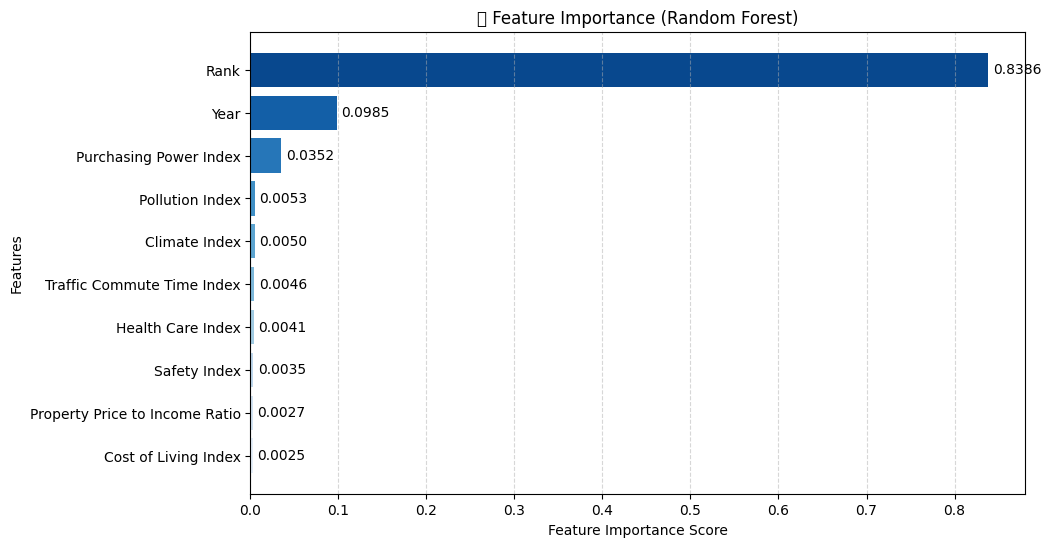

In [36]:
importances = pd.Series(rf_model.feature_importances_, index=x_features.columns)
importances_sorted = importances.sort_values(ascending=True)  # Sorted for horizontal bar chart

# Define color gradient
colors = sns.color_palette("Blues", len(importances_sorted))

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(importances_sorted.index, importances_sorted, color=colors)

# Add labels
for bar in bars:
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
             f"{bar.get_width():.4f}", va='center', fontsize=10)

plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("🔍 Feature Importance (Random Forest)")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


<a id="A"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:5px; color:white; margin:0; font-size:90%; font-family:Pacifico; background-color:skyblue; overflow:hidden"><b> Conclusion </b></div>

##### The Random Forest model achieved strong performance metrics:

Mean Absolute Error (MAE): 3.6519

Root Mean Squared Error (RMSE): 5.5360

R² Score: 0.9800 (indicating 98% of variance explained)

## "If you found this helpful, please upvote! ⭐"